In [4]:
# system imports
import os
import sys
import re
from pathlib import Path

# torch imports
import torch
from lightning import LightningModule, Trainer
from lightning.pytorch.callbacks import EarlyStopping

# project imports 
from core.models import DeepReLUClassifier 
from core.data import MNISTLightningDataModule 
from core.bias import RidgeBias 
from core.estimators import BiasWithCrossEntropy 

# wandb imports
import wandb
import pandas as pd

# data visualization imports
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use("../clean_fig.mplstyle")

def make_dropout_summary_df(runs):
    import re
    rows = []
    for run in runs:
        # get run config
        config = run.config
        # get run metrics
        metrics = run.summary
        # get gpu memory and utilization
        system_metrics = run.system_metrics
        # get gpu memory and utilization by regex
        system_metrics = {k: v for k, v in system_metrics.items() if re.match(r"^system\.gpu\.\d+\.(gpu|memory)$", k)}
        # append to rows
        rows.append({"run_id": run.id, **config, **metrics, **system_metrics})
    return pd.DataFrame(rows)


def panelplot(data, x, y, hue=None, **kwargs):
    ax = plt.gca()
    ax.grid(True, color="lightgray", linestyle="--", linewidth=0.5)
    if hue is not None:
        norm = mpl.colors.Normalize(vmin=data[hue].min(), vmax=data[hue].max())
        palette = "Blues"
    else:
        norm = None
        palette = None
    # plot violin plot
    sns.violinplot(
        data=data,
        x=x,
        y=y,
        inner=None,
        cut=0,
        density_norm="width",
        color="lightgray",
        alpha=0.5,
        ax=ax,
    )
    sns.stripplot(
        data=data,
        x=x,
        y=y,
        size=5,
        linewidth=0.5,
        hue=hue,
        hue_norm=norm,
        alpha=0.6,
        palette=palette,
        edgecolor="auto",
        ax=ax,
    )

## Access previous runs

In [ ]:
api = wandb.Api(timeout=60)
user_org = "jhrudoler-penn"
project_name = "inductive-bias"
sweep_id = "2stzqc65"
sweep = api.sweep(f"{user_org}/{project_name}/{sweep_id}")
runs = sweep.runs  # automatically filtered to that sweep

def download_checkpoint(run, alias="best"):  # alias "latest" or explicit step also works
    artifacts = run.logged_artifacts()
    model_artifacts = [a for a in artifacts if a.type == "model"]
    # pick the latest matching alias
    for artifact in sorted(model_artifacts, key=lambda a: a.created_at, reverse=True):
        if alias in artifact.aliases:
            artifact_dir = artifact.download()
            # Lightning checkpoints are usually named `model.ckpt`
            return Path(artifact_dir) / "model.ckpt"
    raise FileNotFoundError(f"No checkpoint with alias '{alias}' for run {run.name}")

def load_model_from_run(run):
    cfg = run.config
    print(cfg)
    model = DeepReLUClassifier(
        input_dim=28*28,
        width=cfg["width"],
        depth=cfg["depth"],
        dropout=cfg["dropout"],
        batchnorm=cfg["batchnorm"],
        lr=cfg["lr"],
        momentum=cfg["momentum"],
        l2_penalty=cfg["l2_penalty"],
    )
    ckpt_path = download_checkpoint(run, alias="best")  # or "latest"
    state_dict = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state_dict["state_dict"])
    model.eval()
    return model

In [4]:
def fit_bias_for_run(run):
    model = load_model_from_run(run)
    # Build whichever bias model(s) you want
    bias_model = RidgeBias()
    estimator = BiasWithCrossEntropy(
        predictive_model=model.eval(),
        bias_model=bias_model,
    )
    dm = MNISTLightningDataModule(root="~/inductive-bias/MNIST", batch_size=run.config["batch_size"], num_workers=run.config.get("num_workers", 4))
    trainer = Trainer(max_epochs=200, accelerator="auto", devices=1, callbacks=[EarlyStopping(monitor="train/loss", patience=20)])
    dm.setup("fit")
    trainer.fit(estimator, datamodule=dm)
    return bias_model.get_bias_params()

In [ ]:
# get df of run configs and metrics

rows = []
for run in runs:
    # get run config
    config = run.config
    # get run metrics
    metrics = run.summary
    # append to rows
    rows.append({"run_id": run.id, **config, **metrics})
df_summary = pd.DataFrame(rows)
df_summary.head()


,run_id,lr,seed,depth,width,epochs,bias_lr,dropout,momentum,batchnorm,...,bias/bias_models.1.beta,epoch,estimated_nuclear_norm,estimated_ridge,train/accuracy_epoch,train/loss,train/loss_epoch,trainer/global_step,val/accuracy,val/loss
0,i21tj69p,0.005,42,5,256,500,0.05,0.0,0.9,False,...,-10.441648,179,0.000029,0.000026,1.000000,5.213797e-09,0.000395,37979,0.971500,0.161737
1,uk9xon6j,0.005,123,5,256,500,0.05,0.0,0.9,False,...,-10.709434,219,0.000022,0.000020,1.000000,2.618464e-09,0.000370,46419,0.972000,0.154332
2,q7omaj3k,0.005,51,3,256,500,0.05,0.9,0.9,False,...,-11.879230,206,0.000007,0.000885,0.639167,1.371493e-06,1.015245,43676,0.746833,0.760233
3,jyqn3mmq,0.005,432,3,256,500,0.05,0.9,0.9,False,...,-10.082605,146,0.000042,0.000624,0.601593,1.092634e-06,1.039023,31016,0.659333,0.836469
4,0fffrvg6,0.005,643,3,256,500,0.05,0.9,0.9,False,...,-10.118527,134,0.000040,0.000688,0.623370,1.212575e-06,0.986982,28484,0.692500,0.786135


In [10]:
df_summary["depth"].value_counts()

depth
3    100
1    100
5      2
Name: count, dtype: int64

<Axes: xlabel='dropout', ylabel='estimated_ridge'>

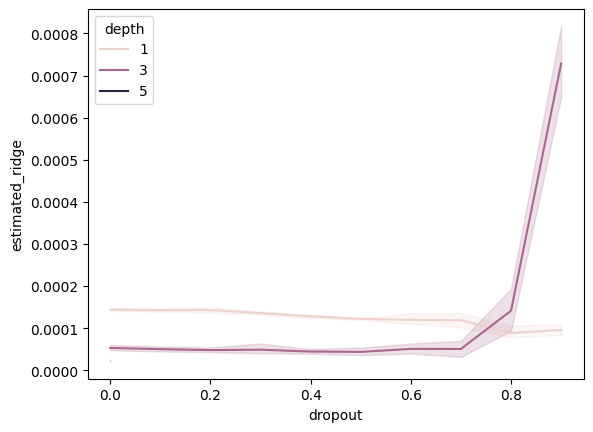

In [ ]:
# Seaborn faceted plot of estimated_ridge as a function of dropout, facets covering different depths
sns.lineplot(data=df_summary, x="dropout", y="estimated_ridge", hue="depth")


## Re-fit bias models

In [ ]:
rows = []
for run in runs:
    try:
        bias_value = fit_bias_for_run(run)
        rows.append({"run_id": run.id, "seed": run.config["seed"], "dropout": run.config["dropout"], "bias": bias_value})
    except Exception as exc:
        print(f"Skipping {run.name}: {exc.__class__.__name__}: {exc}")

df = pd.DataFrame(rows)
df.head()

{'lr': 0.005, 'seed': 42, 'depth': 5, 'width': 256, 'epochs': 500, 'bias_lr': 0.05, 'dropout': 0, 'momentum': 0.9, 'batchnorm': False, 'input_dim': 784, 'batch_size': 256, 'l2_penalty': 0, 'optimizer_cls': 'Adam', 'num_data_workers': 4, 'grad_match_loss_fn': 'mse_loss'}


wandb:   1 of 1 files downloaded.  
/home/jrudoler/inductive-bias/.venv/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jrudoler/inductive-bias/.venv/lib/python3.12/s ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
100%|██████████| 9.91M/9.91M [00:01<00:00, 6.63MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 6.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 23.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 28.1MB/s]
/home/jrudoler/inductive-bias/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You pass

Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


Skipping stellar-sweep-202: NameError: name 'exit' is not defined
{'lr': 0.005, 'seed': 123, 'depth': 5, 'width': 256, 'epochs': 500, 'bias_lr': 0.05, 'dropout': 0, 'momentum': 0.9, 'batchnorm': False, 'input_dim': 784, 'batch_size': 256, 'l2_penalty': 0, 'optimizer_cls': 'Adam', 'num_data_workers': 4, 'grad_match_loss_fn': 'mse_loss'}


wandb:   1 of 1 files downloaded.  
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name             | Type                    | Params | Mode 
---------------------------------------------------------------------
0 | predictive_model | DeepReLULightningModule | 466 K  | eval 
1 | bias_model       | RidgeBias               | 1      | train
---------------------------------------------------------------------
466 K     Trainable params
0         Non-trainable params
466 K     Total params
1.867     Total estimated model params size (MB)
1         Modules in train mode
18        Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

## Visualize sweep results

In [ ]:
# get df of run configs and metrics
# no max columns
pd.set_option("display.max_columns", None)

sweep_id = "3ueveg4e"
user_org = "jhrudoler-penn"
project_name = "inductive-bias-experiments"
full_sweep_id = f"{user_org}/{project_name}/{sweep_id}"
api = wandb.Api(timeout=60)
sweep = api.sweep(full_sweep_id)
runs = sweep.runs

rows = []
for run in runs:
    # check that the run is finished
    if run.state != "finished":
        continue
    # get run config
    config = run.config
    # get run metrics
    metrics = run.summary
    # get run system metrics
    system_metrics = run.system_metrics
    # get run gpu memory and utilization by regex
    system_metrics = {k: v for k, v in system_metrics.items() if re.match(r"^system\.gpu\.\d+\.(gpu|memory)$", k)}
    # append to rows
    rows.append({"run_id": run.id, **config, **metrics, **system_metrics})
df_summary = pd.DataFrame(rows)
df_summary.head()

,run_id,lr,seed,depth,width,bias_lr,dataset,patience,input_dim,l2_lambda,batch_size,max_epochs,num_classes,val_fraction,bias_patience,optimizer_cls,bias_max_epochs,linear_layer_bias,grad_match_loss_fn,_runtime,_step,_timestamp,_wandb,epoch,l2/abs_error,l2/estimated,l2/rel_error,l2/true,l2_abs_error,l2_estimated,l2_rel_error,l2_true,test/acc,test/loss,train/acc,train/loss,train_bias/beta,train_bias/beta_grad,train_bias/loss,trainer/global_step,val/acc,val/loss,system.gpu.0.gpu,system.gpu.0.memory
0,4ismgnk2,0.001,111,5,512,0.1,mnist,50,784,0.500,256,500,10,0.1,100,Adam,3000,True,mse_loss,451.781720,1329,1.762941e+09,{'runtime': 451},289,0.468305,0.031695,0.936611,0.500,0.468305,0.031695,0.936611,0.500,0.1028,2.303138,0.104407,2.303174,-3.451605,6.721932e-12,2.729750e-11,61149,0.109333,2.303140,19,2
1,uyhddhiz,0.001,170,5,256,0.1,mnist,50,784,0.001,256,500,10,0.1,100,Adam,3000,True,mse_loss,396.431430,1073,1.762941e+09,{'runtime': 396},197,0.000721,0.001721,0.720916,0.001,0.000721,0.001721,0.720916,0.001,0.1135,2.301995,0.112519,2.302076,-6.364899,5.783587e-12,7.405532e-11,41749,0.111000,2.302014,15,0
2,63186xd1,0.001,85,5,256,0.1,mnist,50,784,0.001,256,500,10,0.1,100,Adam,3000,True,mse_loss,263.614145,712,1.762941e+09,{'runtime': 263},136,0.000945,0.001945,0.944892,0.001,0.000945,0.001945,0.944892,0.001,0.1135,2.301996,0.112519,2.302077,-6.242549,2.257940e-11,9.511823e-11,28899,0.111000,2.302008,13,0
3,f6ypqfhj,0.001,999,5,512,0.1,mnist,50,784,0.001,256,500,10,0.1,100,Adam,3000,True,mse_loss,274.483483,697,1.762941e+09,{'runtime': 274},134,0.001921,0.002921,1.920852,0.001,0.001921,0.002921,1.920852,0.001,0.1135,2.301997,0.112519,2.302078,-5.835880,2.984897e-11,5.300720e-11,28449,0.111000,2.302009,17,2
4,34wf0344,0.001,999,5,128,0.1,mnist,50,784,0.001,256,500,10,0.1,100,Adam,3000,True,mse_loss,419.692705,1244,1.762941e+09,{'runtime': 419},265,0.000343,0.001343,0.343379,0.001,0.000343,0.001343,0.343379,0.001,0.1135,2.301995,0.112519,2.302076,-6.612567,2.002812e-11,1.464132e-10,56099,0.111000,2.302013,13,0


In [24]:
[k for k in run.history_keys['keys'] if "gpu" in k]

['system/gpu.0.gpu',
 'system/gpu.0.memory',
 'system/gpu.0.memoryAllocated',
 'system/gpu.0.memoryAllocatedBytes',
 'system/gpu.0.powerPercent',
 'system/gpu.0.powerWatts',
 'system/gpu.0.temp',
 'system/gpu.process.0.gpu',
 'system/gpu.process.0.memory',
 'system/gpu.process.0.memoryAllocated',
 'system/gpu.process.0.memoryAllocatedBytes',
 'system/gpu.process.0.powerPercent',
 'system/gpu.process.0.powerWatts',
 'system/gpu.process.0.temp']

In [27]:
# history of gpu memory and utilization
gpu_history = run.history(keys=[k for k in run.history_keys['keys'] if "gpu" in k])
gpu_history.head()


""


In [5]:
system_metrics_df = pd.DataFrame()
for run in runs:
    # get run system metrics
    system_metrics = run.system_metrics
    # get run gpu memory and utilization
    # make a df with columns for each metric matching system.gpu.*.gpu and system.gpu.*.memory
    # filter out other metrics
    system_metrics_df = pd.concat([system_metrics_df, pd.DataFrame(system_metrics, index=[0])])
system_metrics_df["run_id"] = [run.id for run in runs]
system_metrics_df = system_metrics_df.filter(regex=r"^system\.gpu\.\d+\.(gpu|memory)$")
# rename columns to remove the system.gpu. prefix
system_metrics_df.columns = [col.replace("system.", "") for col in system_metrics_df.columns]
system_metrics_df

,gpu.0.gpu,gpu.0.memory
0,19,2
0,15,0
0,17,2
0,13,0
0,13,0
...,...,...
0,6,0
0,6,0
0,1,0
0,8,0


In [4]:
# gpu memory and utilization
df_summary.columns

Index(['run_id', 'lr', 'seed', 'depth', 'width', 'bias_lr', 'dataset',
       'patience', 'input_dim', 'l2_lambda', 'batch_size', 'max_epochs',
       'num_classes', 'val_fraction', 'bias_patience', 'optimizer_cls',
       'bias_max_epochs', 'linear_layer_bias', 'grad_match_loss_fn',
       '_runtime', '_step', '_timestamp', '_wandb', 'epoch', 'l2/abs_error',
       'l2/estimated', 'l2/rel_error', 'l2/true', 'l2_abs_error',
       'l2_estimated', 'l2_rel_error', 'l2_true', 'test/acc', 'test/loss',
       'train/acc', 'train/loss', 'train_bias/beta', 'train_bias/beta_grad',
       'train_bias/loss', 'trainer/global_step', 'val/acc', 'val/loss'],
      dtype='object')

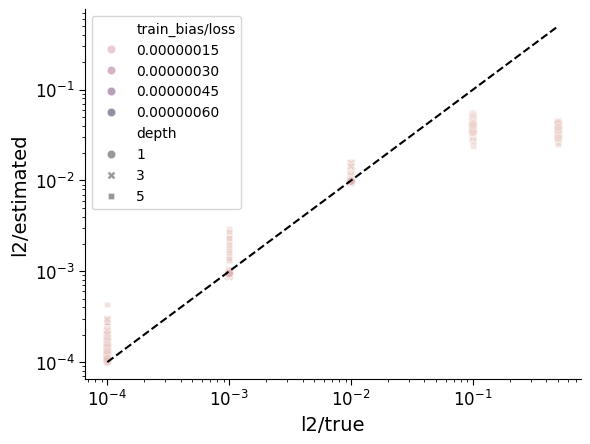

In [ ]:
# scatterplot of l2/true vs l2/estimated
ax = sns.scatterplot(
    data=df_summary, 
    x="l2/true", 
    y="l2/estimated", 
    hue="train_bias/loss", 
    style="depth",
    alpha=0.5
)
ax.set_xscale("log")
ax.set_yscale("log")
# add 1:1 line
ax.plot(
    [min(df_summary["l2/true"]), max(df_summary["l2/true"])],
    [min(df_summary["l2/true"]), max(df_summary["l2/true"])],
    color="k",
    linestyle="--",
)


ValueError: Supply a 'c' argument or a 'color' kwarg but not both; they differ but their functionalities overlap.

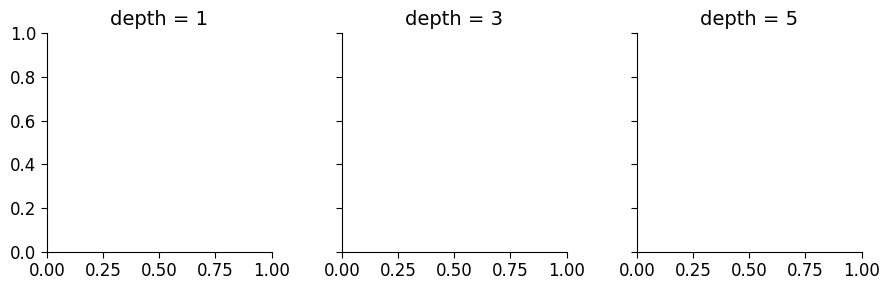

In [6]:
# facetgrid of l2/true vs l2/estimated, facets covering different depths
facet_data = df_summary.query("`l2/true` < 0.1")
g = sns.FacetGrid(facet_data, col="depth", col_wrap=3)
# color by train/loss, remove the default colorbar      
g.map_dataframe(sns.scatterplot, x="l2/true", y="l2/estimated", c="train/loss",)
# show colorbar
g.set(xscale="log", yscale="log")
# add 1:1 line to each facet
def refline(x,**kwargs):
    plt.plot(
        [min(x), max(x)],
        [min(x), max(x)],
        color="k",
        linestyle="--",
    )
g.map(refline, "l2/true")


In [66]:
df_summary.groupby(["l2/true", "depth"]).agg({"l2/rel_error": "mean", "train/acc": "mean"})
df_summary.groupby(["l2/true", "depth"]).count()

run_id  lr  seed  width  bias_lr  dataset  patience  input_dim  \
l2/true depth                                                                   
0.0001  1          34  34    34     34       34       34        34         34   
        3          30  30    30     30       30       30        30         30   
        5          30  30    30     30       30       30        30         30   
0.0010  1          30  30    30     30       30       30        30         30   
        3          30  30    30     30       30       30        30         30   
        5          30  30    30     30       30       30        30         30   
0.0100  1          30  30    30     30       30       30        30         30   
        3          30  30    30     30       30       30        30         30   
        5          30  30    30     30       30       30        30         30   
0.1000  1          30  30    30     30       30       30        30         30   
        3          30  30    30     30       30       30        30         30   
        5          30  30    30     30       30       30        30         30   
0.5000  1          30  30    30     30       30       30        30         30   
        3          30  30    30     30       30       30        30         30   
        5          30  30    30     30       30       30        30         30   

               l2_lambda  batch_size  max_epochs  num_classes  val_fraction  \
l2/true depth                                                                 
0.0001  1             34          34          34           34            34   
        3             30          30          30           30            30   
        5             30          30          30           30            30   
0.0010  1             30          30          30           30            30   
        3             30          30          30           30            30   
        5             30          30          30           30            30   
0.0100  1             30          30          30           30            30   
        3             30          30          30           30            30   
        5             30          30          30           30            30   
0.1000  1             30          30          30           30            30   
        3             30          30          30           30            30   
        5             30          30          30           30            30   
0.5000  1             30          30          30           30            30   
        3             30          30          30           30            30   
        5             30          30          30           30            30   

               bias_patience  optimizer_cls  bias_max_epochs  \
l2/true depth                                                  
0.0001  1                 34             34               34   
        3                 30             30               30   
        5                 30             30               30   
0.0010  1                 30             30               30   
        3                 30             30               30   
        5                 30             30               30   
0.0100  1                 30             30               30   
        3                 30             30               30   
        5                 30             30               30   
0.1000  1                 30             30               30   
        3                 30             30               30   
        5                 30             30               30   
0.5000  1                 30             30               30   
        3                 30             30               30   
        5                 30             30               30   

               linear_layer_bias  grad_match_loss_fn  _runtime  _step  \
l2/true depth                                                           
0.0001  1                     34                  34      

In [ ]:

# helper function to get full trajectory of train_bias/loss from run
def get_train_bias_loss_trajectory(run):
    # get train_bias/loss from run
    train_bias_loss = run.history(keys=["train/loss", "train/acc"], pandas=True)
    # return as dataframe
    return train_bias_loss

losses = get_train_bias_loss_trajectory(runs[0])



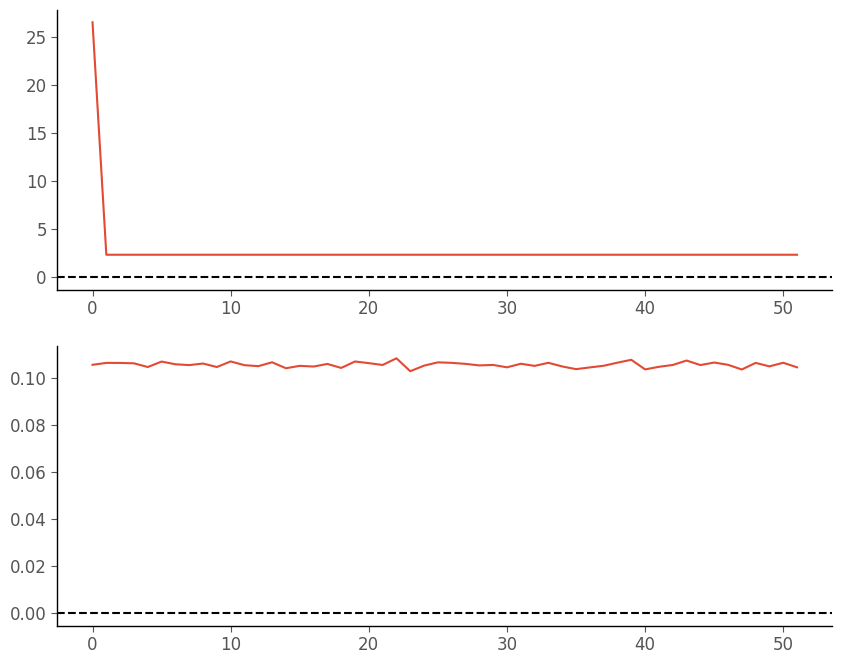

In [49]:
# plot train/loss and train/acc on separate subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
losses["train/loss"].plot(ax=ax1)
ax1.axhline(y=0.0, color="k", linestyle="--")
losses["train/acc"].plot(ax=ax2)
plt.axhline(y=0.0, color="k", linestyle="--")
plt.show()


## For dropout sweep

In [3]:
sweep_id = "chiy2qjz"
user_org = "jhrudoler-penn"
project_name = "inductive-bias"
full_sweep_id = f"{user_org}/{project_name}/{sweep_id}"
api = wandb.Api(timeout=60)
sweep = api.sweep(full_sweep_id)
runs = sweep.runs

In [12]:
for a in runs[0].logged_artifacts():
    path = a.download(root=Path("~/inductive-bias/logs").expanduser() / "artifacts" / a.name)
    print(path)


wandb:   1 of 1 files downloaded.  


/home/jrudoler/inductive-bias/logs/artifacts/run-qkyejnf3-history:v0


In [ ]:
df_dropout_summary = make_dropout_summary_df(runs)
# remove depth=1 run which did not apply dropout
df_dropout_summary = df_dropout_summary[df_dropout_summary["depth"] != 1]
df_dropout_summary.head()

,run_id,lr,seed,depth,width,epochs,bias_lr,dropout,momentum,batchnorm,...,train/acc,train/loss,train_bias/bias_models.0.beta,train_bias/bias_models.0.beta_grad,train_bias/loss,trainer/global_step,val/acc,val/loss,system.gpu.0.gpu,system.gpu.0.memory
0,qkyejnf3,0.05,51,5,512,500,0.05,0.5,0.9,False,...,0.993870,0.020725,-7.700978,1.239126e-09,1.670596e-09,24449,0.980667,0.099441,16,2
1,gdqqe3ta,0.05,51,5,256,500,0.05,0.5,0.9,False,...,0.983981,0.057735,-5.498551,2.056948e-07,1.295849e-07,13749,0.974667,0.134528,6,0
2,ivh6wf3s,0.05,51,5,128,500,0.05,0.5,0.9,False,...,0.966574,0.132739,-5.013578,1.088338e-06,7.956066e-07,17999,0.965667,0.191507,7,0
3,tffdmtgr,0.05,432,5,512,500,0.05,0.5,0.9,False,...,0.992444,0.024299,-6.850098,6.838733e-09,9.259648e-09,24449,0.978000,0.108091,18,3
4,y16u39kh,0.05,432,5,256,500,0.05,0.5,0.9,False,...,0.984185,0.056607,-5.492759,2.065160e-07,1.393655e-07,14999,0.974833,0.139244,12,0


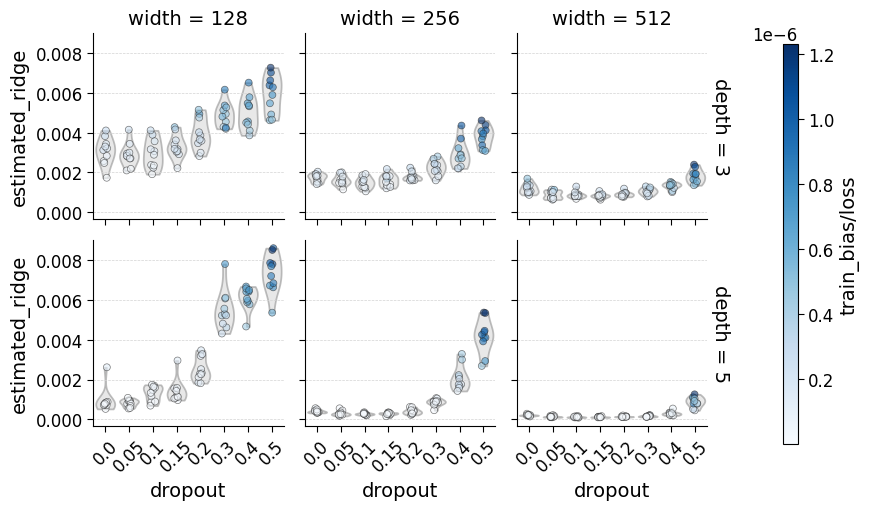

In [ ]:
g = sns.FacetGrid(
    df_dropout_summary,
    col="width",
    row="depth",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=2.5,
    aspect=1,
)
g.map_dataframe(panelplot, x="dropout", y="estimated_ridge", hue="train_bias/loss")

# add colorbar
cax = g.figure.add_axes([1.05, 0.1, 0.02, 0.8])
norm = mpl.colors.Normalize(
    vmin=df_dropout_summary["train_bias/loss"].min(),
    vmax=df_dropout_summary["train_bias/loss"].max(),
)
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = g.figure.colorbar(sm, cax=cax)
cbar.set_label("train_bias/loss")

g.set_axis_labels("dropout", "estimated_ridge")
# rotate x-axis labels
g.tick_params(axis="x", rotation=45)
plt.savefig("../results/figures/dropout_bias_ridge_panel.png", dpi=300)

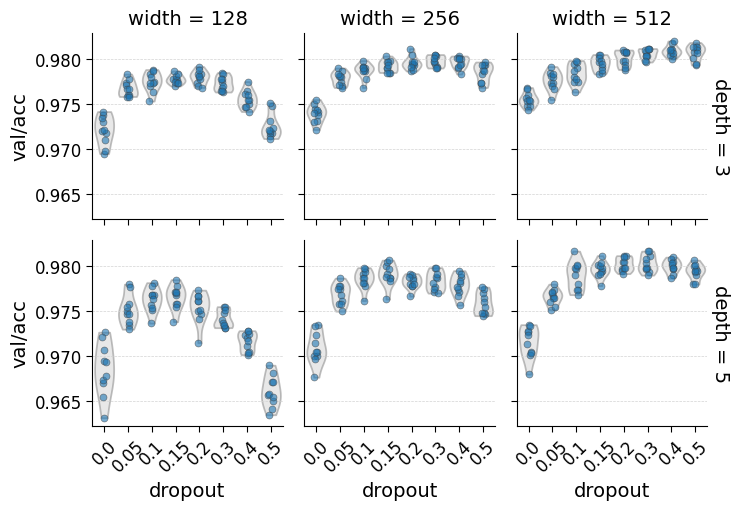

In [81]:
# same figure but with val/acc on the y-axis
g = sns.FacetGrid(
    df_dropout_summary,
    col="width",
    row="depth",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=2.5,
    aspect=1,
)
g.map_dataframe(panelplot, x="dropout", y="val/acc")
g.set_axis_labels("dropout", "val/acc")
g.tick_params(axis="x", rotation=45)
plt.savefig("../results/figures/dropout_bias_ridge_panel_val_acc.png", dpi=300)

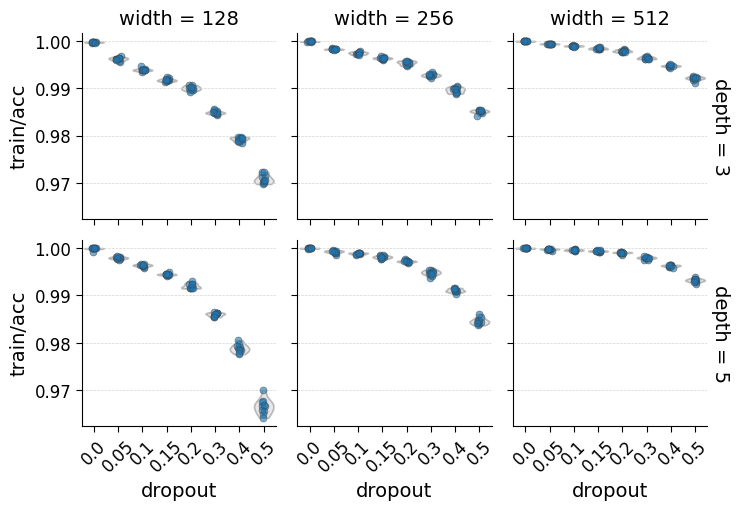

In [77]:
# same with train/acc on the y-axis
g = sns.FacetGrid(
    df_dropout_summary,
    col="width",
    row="depth",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=2.5,
    aspect=1,
)
g.map_dataframe(panelplot, x="dropout", y="train/acc")
g.set_axis_labels("dropout", "train/acc")
g.tick_params(axis="x", rotation=45)
plt.savefig("../results/figures/dropout_bias_ridge_panel_train_acc.png", dpi=300)


## Mixed bias

In [36]:
sweep_id = "00rb3gsn"
user_org = "jhrudoler-penn"
project_name = "inductive-bias"
full_sweep_id = f"{user_org}/{project_name}/{sweep_id}"
api = wandb.Api(timeout=60)
sweep = api.sweep(full_sweep_id)
runs = sweep.runs

df_mixed_summary = make_dropout_summary_df(runs)

# wide to long stacking estimated_ridge and estimated_nuclear_norm
df_mixed_summary = pd.melt(
    df_mixed_summary,
    id_vars=["run_id", "width", "depth", "dropout", "seed", "train_bias/loss", "train/acc", "val/acc", "train_bias/bias_models.0.beta_grad", "train_bias/bias_models.1.beta_grad"],
    value_vars=["estimated_ridge", "estimated_nuclear_norm"],
    var_name="bias_type",
    value_name="estimated_bias",
)


/tmp/ipykernel_127180/2363893877.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


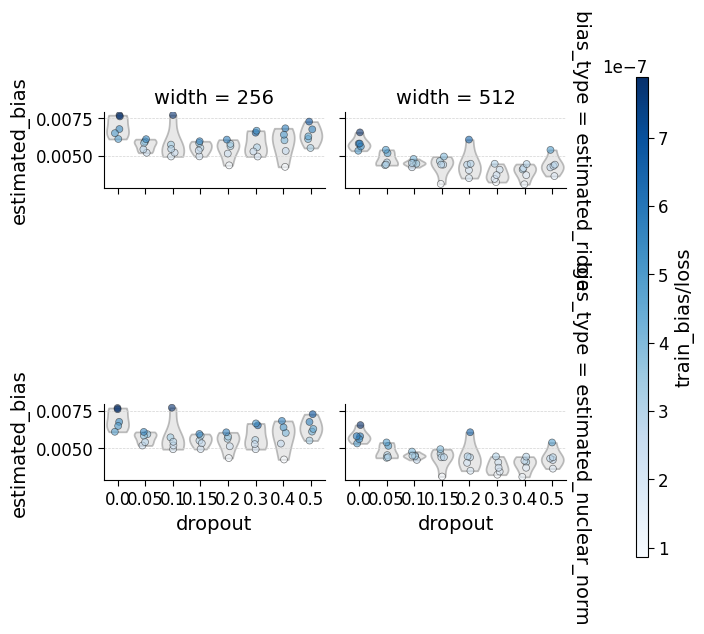

In [37]:
g = sns.FacetGrid(
    df_mixed_summary,
    col="width",
    row="bias_type",
    sharex=True,
    sharey=True,
    margin_titles=True,
)
g.map_dataframe(panelplot, x="dropout", y="estimated_bias", hue="train_bias/loss")

# add colorbar
cax = g.figure.add_axes([1.05, 0.1, 0.02, 0.8])
norm = mpl.colors.Normalize(
    vmin=df_mixed_summary["train_bias/loss"].min(),
    vmax=df_mixed_summary["train_bias/loss"].max(),
)
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = g.figure.colorbar(sm, cax=cax)
cbar.set_label("train_bias/loss")
plt.tight_layout()


In [15]:
import torch
p = torch.nn.Parameter(torch.empty(1, 1), requires_grad=True)
torch.nn.init.kaiming_normal_(p.data)
print(p.data)
# accumulate grad in short training loop
optimizer = torch.optim.SGD([p], lr=0.01)
ref = torch.tensor(5.0)
loss_fn = torch.nn.MSELoss()
for i in range(10):
    optimizer.zero_grad()
    loss = loss_fn(p, ref)
    loss.backward()
    print(p.grad, p.data)
    optimizer.step( )
p.grad.zero_()
print(p.grad)

tensor([[-1.3290]])
tensor([[-12.6580]]) tensor([[-1.3290]])
tensor([[-12.4049]]) tensor([[-1.2024]])
tensor([[-12.1568]]) tensor([[-1.0784]])
tensor([[-11.9136]]) tensor([[-0.9568]])
tensor([[-11.6754]]) tensor([[-0.8377]])
tensor([[-11.4419]]) tensor([[-0.7209]])
tensor([[-11.2130]]) tensor([[-0.6065]])
tensor([[-10.9888]]) tensor([[-0.4944]])
tensor([[-10.7690]]) tensor([[-0.3845]])
tensor([[-10.5536]]) tensor([[-0.2768]])
tensor([[0.]])


/home/jrudoler/inductive-bias/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [32]:
# test how collinear the grads of the bias models for ridge and nuclear norm are
from core.bias import RidgeBias, NuclearNormBias, JointBias
from lightning.pytorch.callbacks import Callback
from lightning.pytorch import Trainer, LightningModule
from core.estimators import BiasWithMSE
from torch.utils.data import TensorDataset, DataLoader

ridge_bias = RidgeBias()
nuclear_norm_bias = NuclearNormBias()
joint_bias = JointBias([ridge_bias, nuclear_norm_bias])

# create a random weight matrix
weight_vector = torch.randn(10)

n_samples = 100
input = torch.randn(n_samples, 10)
# linear relationship between input and target
target = input @ weight_vector + torch.randn(n_samples)
dataset = TensorDataset(input, target)
dataloader = DataLoader(dataset, batch_size=10)
# compute the grads of the bias models

# train a linear layer to predict target from input
linear = torch.nn.Linear(10, 1)
# optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)
# for i in range(10):
#     optimizer.zero_grad()
#     loss = loss_fn(linear(input), target)
#     loss.backward()
#     optimizer.step()

estimator = BiasWithMSE(
    predictive_model=linear,
    bias_model=joint_bias,
    lr=0.1,
)

# callback to print the cosine similarity between the grads of the bias models
# should be called on each batch
# class PrintBiasGrads(Callback):
#     def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
#         # Access the beta parameters from the joint bias model
#         beta_grads = []
#         for bias_module in pl_module.bias_model.bias_models:
#             if hasattr(bias_module, 'beta') and bias_module.beta.grad is not None:
#                 beta_grads.append(bias_module.beta.grad.item())
        
#         if len(beta_grads) >= 2:
#             # Log individual gradients
#             pl_module.log("grad_beta0", beta_grads[0], prog_bar=True)
#             pl_module.log("grad_beta1", beta_grads[1], prog_bar=True)
            
#             # Log the ratio (another way to see if they're proportional)
#             if abs(beta_grads[1]) > 1e-8:
#                 ratio = beta_grads[0] / beta_grads[1]
#                 pl_module.log("grad_ratio", ratio, prog_bar=True)

# trainer = Trainer(max_epochs=100, callbacks=[PrintBiasGrads()])
# trainer.fit(estimator, dataloader)




In [34]:
class CheckPenaltyCorrelation(Callback):
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        if batch_idx % 10 == 0:  # Check every 10 batches to avoid slowdown
            X, y = batch
            
            # Get flattened params (same as in training_step)
            params = dict(pl_module.predictive_model.named_parameters())
            flattened_params = torch.cat([p.view(-1) for p in params.values()])
            flattened_params = flattened_params.detach().requires_grad_()
            
            # Recreate named_param_views
            offset = 0
            named_param_views = {}
            for name, param in params.items():
                numel = param.numel()
                view = flattened_params[offset : offset + numel].view_as(param)
                named_param_views[name] = view
                offset += numel
            
            # Compute individual penalties
            ridge_penalty = torch.sum(flattened_params.pow(2))
            nuclear_penalty = sum(
                torch.linalg.matrix_norm(
                    p if p.ndim == 2 else p.reshape(p.shape[0], -1), ord="nuc"
                )
                for p in named_param_views.values() if p.ndim >= 2
            )
            
            # Get their gradients w.r.t. parameters
            grad_ridge = torch.autograd.grad(
                ridge_penalty, flattened_params, create_graph=False
            )[0]
            grad_nuclear = torch.autograd.grad(
                nuclear_penalty, flattened_params, create_graph=False
            )[0]
            
            # Compute cosine similarity
            cos_sim = torch.nn.functional.cosine_similarity(
                grad_ridge.unsqueeze(0), 
                grad_nuclear.unsqueeze(0)
            )
            
            pl_module.log("penalty_grad_correlation", cos_sim.item(), prog_bar=True)

trainer = Trainer(max_epochs=100, callbacks=[CheckPenaltyCorrelation()])
trainer.fit(estimator, dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name             | Type      | Params | Mode 
-------------------------------------------------------
0 | predictive_model | Linear    | 11     | train
1 | bias_model       | JointBias | 2      | train
-------------------------------------------------------
13        Trainable params
0         Non-trainable params
13        Total params
0.000     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


In [35]:
# Test with matrices of different condition numbers
import torch
import torch.linalg as LA

for condition_number in [1, 10, 100, 1000]:
    # Create matrix with specific condition number
    U, _ = torch.linalg.qr(torch.randn(10, 5))
    V, _ = torch.linalg.qr(torch.randn(5, 5))
    
    # Singular values from condition_number down to 1
    sigma = torch.linspace(condition_number, 1, 5)
    W = U @ torch.diag(sigma) @ V.T
    
    # Compute gradients
    grad_l2 = 2 * W
    
    # Nuclear norm gradient (requires autograd)
    W_param = W.detach().requires_grad_()
    nuclear = torch.linalg.matrix_norm(W_param, ord='nuc')
    nuclear.backward()
    grad_nuclear = W_param.grad
    
    # Correlation
    cos_sim = torch.nn.functional.cosine_similarity(
        grad_l2.flatten().unsqueeze(0),
        grad_nuclear.flatten().unsqueeze(0)
    )
    
    print(f"Condition number: {condition_number:6.1f}, Correlation: {cos_sim.item():.4f}")

Condition number:    1.0, Correlation: 1.0000
Condition number:   10.0, Correlation: 0.8656
Condition number:  100.0, Correlation: 0.8219
Condition number: 1000.0, Correlation: 0.8170
